In [1]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

In [2]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import mmap
import random
import pickle
import os
import matplotlib.pyplot as plt
import math

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_float32_matmul_precision('high')


# CHANGED: n_layer 1->8, n_head 1->8, block_size 32->64, max_iters 1000->5000
# Bigger model = more capacity to learn patterns
block_size    = 128
batch_size    = 64
max_iters     = 18750
learning_rate = 3e-4
eval_iters    = 250
n_embd        = 384
n_layer       = 8
n_head        = 8
dropout       = 0.2

print(f'Device: {device}')
print(f'n_layer={n_layer} | n_head={n_head} | block_size={block_size} | max_iters={max_iters}')

Device: cuda
n_layer=8 | n_head=8 | block_size=128 | max_iters=18750


In [3]:
import tiktoken
enc = tiktoken.get_encoding("gpt2")

vocab_size = enc.n_vocab  # 50257
encode = lambda s: enc.encode(s, allowed_special={'<|endoftext|>'})
decode = lambda l: enc.decode(l)

print(f"Vocab size: {vocab_size}")

Vocab size: 50257


In [4]:
def get_random_chunk(split):
    filename = 'output_train.txt' if split == 'train' else 'output_val.txt'
    with open(filename, 'rb') as f:
        with mmap.mmap(f.fileno(), 0, access=mmap.ACCESS_READ) as mm:
            file_size = len(mm)
            while True:  # ← keep trying until we get a big enough chunk
                start_pos = random.randint(0, file_size - block_size * batch_size)
                mm.seek(start_pos)
                block = mm.read(block_size * batch_size - 1)
                decoded_block = block.decode('utf-8', errors='ignore')
                data = torch.tensor(encode(decoded_block), dtype=torch.long)
                if len(data) > block_size + batch_size:  # ← only return if big enough
                    return data

def get_batch(split):
    data = get_random_chunk(split)
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

In [5]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

In [6]:
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        wei = q @ k.transpose(-2, -1) * k.shape[-1]**-0.5
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        return wei @ self.value(x)


class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads   = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj    = nn.Linear(head_size * num_heads, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.dropout(self.proj(out))


class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        # CHANGED: ReLU -> GELU (modern standard, performs better in transformers)
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa   = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1  = nn.LayerNorm(n_embd)
        self.ln2  = nn.LayerNorm(n_embd)

    def forward(self, x):
        # CHANGED: Pre-LayerNorm - normalize BEFORE attention, more stable training
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x


class GPTLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding_table    = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks  = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f    = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)  # ← add bias=False
        
        self.token_embedding_table.weight = self.lm_head.weight  # ← before apply
        
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, index, targets=None):
        B, T = index.shape
        tok_emb = self.token_embedding_table(index)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))
        x = self.blocks(tok_emb + pos_emb)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B*T, C), targets.view(B*T))
        return logits, loss

    def generate(self, index, max_new_tokens):
        for _ in range(max_new_tokens):
            index_cond = index[:, -block_size:]
            logits, _ = self.forward(index_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            index_next = torch.multinomial(probs, num_samples=1)
            index = torch.cat((index, index_next), dim=1)
        return index


# CHANGED: checks if pkl exists before loading, starts fresh if not
model = GPTLanguageModel(vocab_size)
if os.path.exists('model-best.pkl'):
    print('Loading best model...')
    with open('model-best.pkl', 'rb') as f:
        model = pickle.load(f)
    print('Loaded successfully - continuing from step ~1250')
else:
    print('Starting fresh')

m = model.to(device)
print(f'Parameters: {sum(p.numel() for p in m.parameters()):,}')

Starting fresh
Parameters: 33,535,104


In [7]:
optimizer     = torch.optim.AdamW(model.parameters(), lr=learning_rate)
scaler        = scaler = torch.amp.GradScaler('cuda')

best_val_loss = float('inf')
train_losses  = []
val_losses    = []
loss_steps    = []

def get_lr(it):
    warmup_iters = 100
    min_lr = learning_rate / 10
    if it < warmup_iters:
        return learning_rate * it / warmup_iters
    decay = (it - warmup_iters) / (max_iters - warmup_iters)
    return min_lr + 0.5 * (learning_rate - min_lr) * (1 + math.cos(math.pi * decay))

for iter in range(max_iters):
    lr = get_lr(iter)
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

    if iter % eval_iters == 0:
        losses = estimate_loss()
        print(f'step {iter:5d} | train: {losses["train"]:.4f} | val: {losses["val"]:.4f} | lr: {lr:.6f}')
        train_losses.append(losses['train'].item())
        val_losses.append(losses['val'].item())
        loss_steps.append(iter)

        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            with open('model-best.pkl', 'wb') as f:
                pickle.dump(model, f)
            print(f'  -> new best saved (val: {best_val_loss:.4f})')

    xb, yb = get_batch('train')

    # CHANGED: mixed precision training
    with torch.amp.autocast('cuda'):
        logits, loss = model(xb, yb)

    optimizer.zero_grad(set_to_none=True)
    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    scaler.step(optimizer)
    scaler.update()

print(f'\nFinal loss: {loss.item():.4f}')
with open('model-01.pkl', 'wb') as f:
    pickle.dump(model, f)
print('Model saved!')

step     0 | train: 10.9076 | val: 10.9073 | lr: 0.000000
  -> new best saved (val: 10.9073)
step   250 | train: 6.7938 | val: 6.7634 | lr: 0.000300
  -> new best saved (val: 6.7634)
step   500 | train: 6.4431 | val: 6.4886 | lr: 0.000300
  -> new best saved (val: 6.4886)
step   750 | train: 6.3029 | val: 6.3123 | lr: 0.000299
  -> new best saved (val: 6.3123)
step  1000 | train: 6.2277 | val: 6.1758 | lr: 0.000298
  -> new best saved (val: 6.1758)
step  1250 | train: 6.1664 | val: 6.0922 | lr: 0.000297
  -> new best saved (val: 6.0922)
step  1500 | train: 5.9861 | val: 6.0422 | lr: 0.000296
  -> new best saved (val: 6.0422)
step  1750 | train: 6.0237 | val: 5.9434 | lr: 0.000295
  -> new best saved (val: 5.9434)
step  2000 | train: 5.8660 | val: 5.8556 | lr: 0.000293
  -> new best saved (val: 5.8556)
step  2250 | train: 5.7815 | val: 5.7881 | lr: 0.000291
  -> new best saved (val: 5.7881)
step  2500 | train: 5.7191 | val: 5.7454 | lr: 0.000289
  -> new best saved (val: 5.7454)
step  2

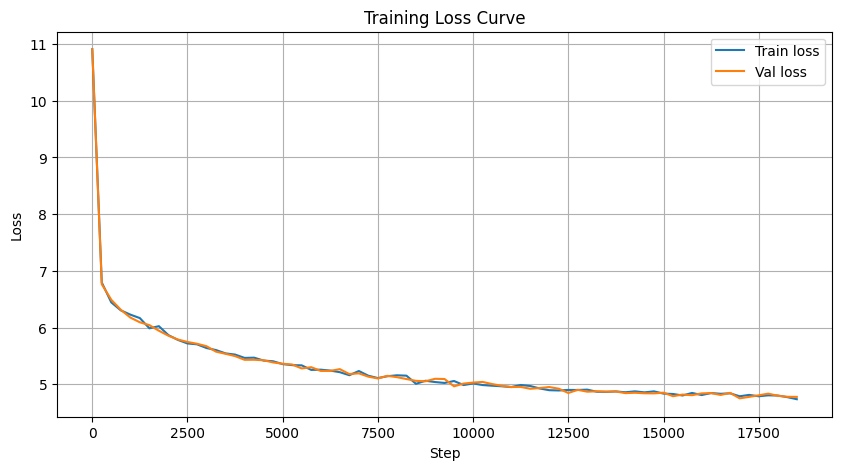

Loss curve saved to loss_curve.png


In [8]:
# NEW: plot loss curve to visualize training progress
plt.figure(figsize=(10, 5))
plt.plot(loss_steps, train_losses, label='Train loss')
plt.plot(loss_steps, val_losses,   label='Val loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.grid(True)
plt.savefig('loss_curve.png')
plt.show()
print('Loss curve saved to loss_curve.png')

In [9]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)
generated_chars = decode(m.generate(context, max_new_tokens=500)[0].tolist())
print(generated_chars)

! Press/ Niño: Shutterstock Advertisement: http.twitter.com/1998.

Trivia [ edit ]

Ott Klux Guards") [ edit ]- Vitala in Beijing, Malaysia, January 17, 2015; CN is a willing maid for animals;

https://2017/55 vegetarian/beans/Please visit az.gif/Breaking Mistieldar-MPorpanny/AIDS-Baurlements required to test the name object to Somalia, I feel like being associated with humans, and óaudas agalic. - Oureen Credyman/Less Product: Global Shankures Pieces and Sales Report

Safety mode [ edit ] is an officer with a school title of this song. The deadline has a planned view, not a rapport or a secreted movie in the seriesignty. The current aspect of The Washington End has received more than $150,000, plus only $5.45 76 International meteorologist Ruth's Holder of Manings' ( >Houston) and the fielding membership in a "COSUs" message that means that Amazon's salary per gift can almost 90,000, $226,500,000. You'd have to mention that fewer merger running offline back on 1992, 24 year, an invest